In [1]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from mpmath import mp
from tqdm.auto import tqdm

In [2]:
plt.style.use('dark_background')

In [3]:
# Compute with high dps in the cell below if you want to use in computations.
# Currently its just used for plotting since its a bit slow to generate.
somos_const = mp.exp(-mp.diff(lambda n: mp.polylog(n, 1/2), 0))
print(somos_const)

1.66168794963359


In [4]:
mp.dps = 501
# You need to redo the assignments below if you change the precision,
# since the constans are evaluated lazily.
K = +mp.khinchin
tau = 2 * +mp.pi

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Continued Fractions')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import sys
# Append parent dir to path, so that other modules can be imported.
sys.path.append('../')

In [7]:
from CF_core import compute_cum_GM, compute_num_from_cf, compute_cf

### Functions to convert between binary and decimal.

In [8]:
from modules.CF_utils import frac_dec_to_bin, frac_bin_to_dec
from modules.CF_utils import compute_binary_diff_coeffs, diff_to_bin

In [9]:
# Sample test.
x = 0.625
digits = frac_dec_to_bin(x, 3)
print(digits)
frac_bin_to_dec(digits)

[1, 0, 1]


mpf('0.625')

In [10]:
# Sample test.
compute_binary_diff_coeffs(mp.pi-3, 20)

array([3, 3, 5, 1, 1, 1, 1, 1, 2, 1])

### Numbers that converge to Somo's constant.

$$PMF(k) = \frac{1}{2^k}$$
$$CDF(k) = 1-\frac{1}{2^k}$$
$$PMF^{-1}(k) = \log_2\left(\frac{1}{k}\right)$$
$$CDF^{-1}(k) = \log_2\left(\frac{1}{1-k}\right)$$

#### Math constants.

Constants like $\pi$, $e$, $\gamma$, $\phi$, $\sqrt2$, $K_0$ and even $C_{10}$ all seem to have this property. \
And of course the number itself has this property.

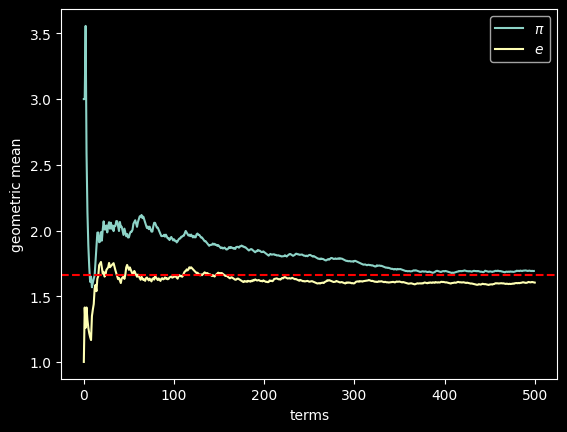

In [ ]:
constants = {
    '$\pi$': (mp.pi, 1022),
    '$e$': (mp.e, 947),
    # '$\phi$': (mp.phi, 969),
    # '$\sqrt{2}$': (mp.sqrt(2), 1019),
    # '$\gamma$': (mp.euler, 980),
}

for x_name, (x, digits) in constants.items():
    diff_coeffs = compute_binary_diff_coeffs(mp.frac(x), digits)
    gms = compute_cum_GM(diff_coeffs)
    plt.plot(gms, label=x_name)


plt.axhline(somos_const, color='r', linestyle='--')
plt.xlabel('terms')
plt.ylabel('geometric mean')
plt.legend()
plt.show()

#### Champernowne constant in base 2 converted to base 10.
Seems to converge slowly but it does follow the geometric distribution $\frac{1}{2^6}$.

Formed by concatenating 1, 10, 11, 100, 101, 110, ... \
$C_2 = 0.11011100101110111..._2$ \
$    = 0.8622401258680545..._{10}$

In [ ]:
C2 = ''.join([f'{i:b}' for i in range(1, 157)])
print('C2 = 0.' + C2[:16])
bin_cf = list(map(int, C2))
C2_10 = frac_bin_to_dec(bin_cf)
print('C2 in base 10 = ', float(C2_10))

C2 = 0.1101110010111011
C2 in base 10 =  0.8622401258680545


The [OEIS entry](https://oeis.org/A030302) provides a formula for the nth term in $C_2$: [1,1,0,1,1,1,0,0,1,0,1,...].

$$a(n) = \left\lfloor 2^{\left( (n + 2^{i} - 2) \% i \right) - i + 1} \cdot \left\lceil \frac{n + 2^{i} - 1}{i} - 1 \right\rceil \right\rfloor \% 2$$
where
$$i = \left\lceil \frac{W\left(\frac{\log(2)}{2} \cdot (n - 1)\right)}{\log(2)} + 1 \right\rceil$$

So $C_2$ in base 10 is given by the formula
$$\sum_{i=1}^{\infty} 2^{-i} \cdot a(i)$$

An exact analytical solution isn't possible due to the complexity of the function a(i) \
involving modular arithmetic and the Lambert W function.


In [ ]:
from scipy.special import lambertw

def compute_C2_10(num_terms=10):
    sum_ = 0
    ln_sqrt_2 = np.log(2) / 2
    for n in range(1, num_terms+1):
        w = lambertw(ln_sqrt_2*(n-1))
        assert np.isreal(w)
        i = np.ceil(w.real/np.log(2) + 1)
        p = 2 ** ( ((n+(2**i)-2)%i) -i + 1 )
        q = np.ceil((n + (2**i) - 1)/i - 1)
        a = np.floor(p*q) % 2
        sum_ += (2**(-n)) * a
    return sum_

compute_C2_10(30)

0.8622401254251599

In [ ]:
diff_coeffs = compute_binary_diff_coeffs(C2_10, 967)
print(diff_coeffs[:25], end='\n\n')

print('frequency counts')
c, v = np.unique(diff_coeffs, return_counts=True)
c, v, np.round(v/v.sum(), 3)

[1 1 2 1 1 3 2 1 1 2 1 1 1 4 3 1 2 2 2 1 1 1 3 1 2]

frequency counts


(array([1, 2, 3, 4, 5, 6, 7, 8]),
 array([286, 127,  63,  30,  13,   5,   2,   1]),
 array([0.543, 0.241, 0.12 , 0.057, 0.025, 0.009, 0.004, 0.002]))

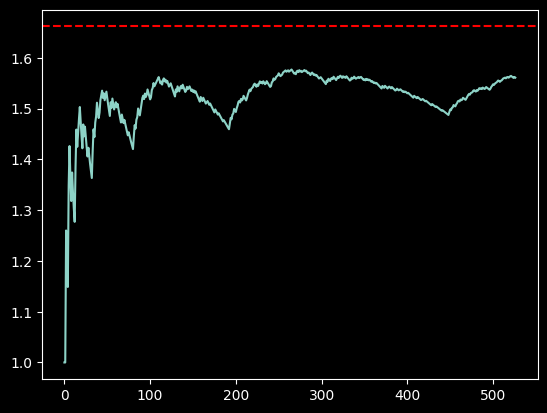

In [ ]:
gms = compute_cum_GM(diff_coeffs)
plt.plot(gms)
plt.axhline(somos_const, color='r', linestyle='--')
plt.show()

#### Random digits after the decimal point.

In [ ]:
x = mp.rand()
diff_coeffs = compute_binary_diff_coeffs(x, 1000)
gm = np.exp(np.log(diff_coeffs).sum() / len(diff_coeffs))
print(f'GM={gm:.6f}, abs_err={abs(float(somos_const)-gm):6f}')
c, v = np.unique(diff_coeffs, return_counts=True)
c, v

GM=1.65422, abs_err=0.007468


(array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([253, 124,  70,  21,  17,  11,   4,   2,   1]))

#### Random 0/1 in the binary representation.

In [ ]:
x_bin = np.random.randint(0, 2, 1000)
x = frac_bin_to_dec(x_bin)

diff_coeffs = compute_binary_diff_coeffs(x, 1000)
gm = np.exp(np.log(diff_coeffs).sum() / len(diff_coeffs))
print(f'GM={gm:.6f}, abs_err={abs(float(somos_const)-gm):.6f}')
c, v = np.unique(diff_coeffs, return_counts=True)
c, v

GM=1.669590, abs_err=0.007902


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 array([246, 131,  48,  31,  20,   9,   5,   2,   1,   1]))

### Numbers that don't converge to the Solom's constant.

#### Random digits in the difference coeffs.

One can just create a list of numbers that dont follow the geometric distribution $PMF(k)=\frac{1}{2^k}$ and generate a number using that.

In [ ]:
bin_diffs = np.random.randint(1, 10, 100)
print(bin_diffs[:25])
x_bin = diff_to_bin(bin_diffs)
if not x_bin[0]:
    x_bin = np.insert(x_bin, 0, 1)
print(x_bin[:25])
x = frac_bin_to_dec(x_bin)
float(x)

[1 1 7 9 7 8 2 4 9 9 1 4 7 2 5 5 2 7 7 3 5 2 8 1 3]
[1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1]


0.7519569696469297

100
[1 1 7 9 7 8 2 4 9 9 1 4 7 2 5 5 2 7 7 3]


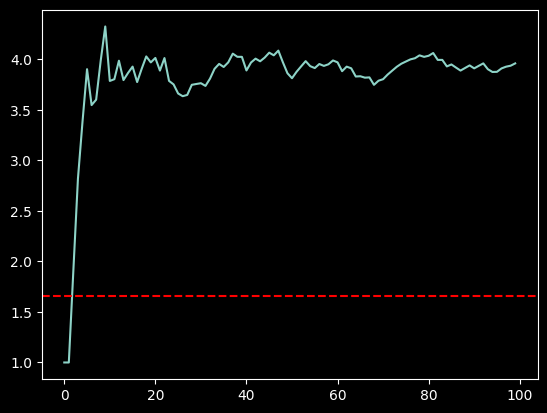

In [ ]:
diff_coeffs = compute_binary_diff_coeffs(x, 1000)
print(len(diff_coeffs))
print(diff_coeffs[:20])
gms = compute_cum_GM(diff_coeffs)
plt.plot(gms)
plt.axhline(somos_const, color='r', linestyle='--')
plt.show()

#### Repeating pattern in the difference coeffs.

In [ ]:
# bin_diffs = list(range(1, 101))
bin_diffs = [1, 1, 5] * 50
print(bin_diffs[:25])
x_bin = diff_to_bin(bin_diffs)
print(x_bin[:25])
x = frac_bin_to_dec(x_bin)
float(x)

[1, 1, 5, 1, 1, 5, 1, 1, 5, 1, 1, 5, 1, 1, 5, 1, 1, 5, 1, 1, 5, 1, 1, 5, 1]
[1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0]


0.7637795275590551

150
[1 1 5 1 1 5 1 1 5 1 1 5 1 1 5 1 1 5 1 1]


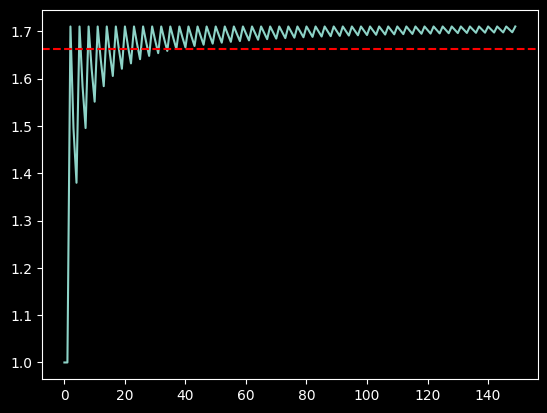

In [ ]:
diff_coeffs = compute_binary_diff_coeffs(x, 1000)
print(len(diff_coeffs))
print(diff_coeffs[:20])
gms = compute_cum_GM(diff_coeffs)
plt.plot(gms)
plt.axhline(somos_const, color='r', linestyle='--')
plt.show()

### Constructing a number to converge to Somos's constant.

In [ ]:
inv_cdf = lambda x: np.log2(1/(1-x))

x = np.linspace(0,1,100000)[1:-1]
coeffs = np.ceil(inv_cdf(x))

print(compute_cum_GM(coeffs)[-1])

1.6616663230405309


In [ ]:
@nb.njit
def pmf_nb(k):
  return 1/(2**k)

@nb.njit
def compute_somos_coeffs(num_coeffs):
  coeffs = []
  counts = [0]
  for _ in range(num_coeffs):
    min_time = np.inf
    for i, count in enumerate(counts):
      time = (count+1) / pmf_nb(i+1)
      if time < min_time:
        min_index = i
        min_time = time
    if min_index == len(counts) - 1:
      counts.append(0)
    counts[min_index] += 1
    coeffs.append(min_index + 1)
  return np.array(coeffs, dtype=np.int64)

In [ ]:
num_steps = 100000
somos_coeffs = compute_somos_coeffs(num_steps)
list(somos_coeffs[:25])

[1, 1, 2, 1, 1, 2, 3, 1, 1, 2, 1, 1, 2, 3, 4, 1, 1, 2, 1, 1, 2, 3, 1, 1, 2]

In [ ]:
somos_bin = diff_to_bin(somos_coeffs[:50032])
somos_bin[:25]
print(somos_bin[:50])

[1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0]


In [ ]:
r = frac_bin_to_dec(somos_bin)
float(r)

0.8641913214950458

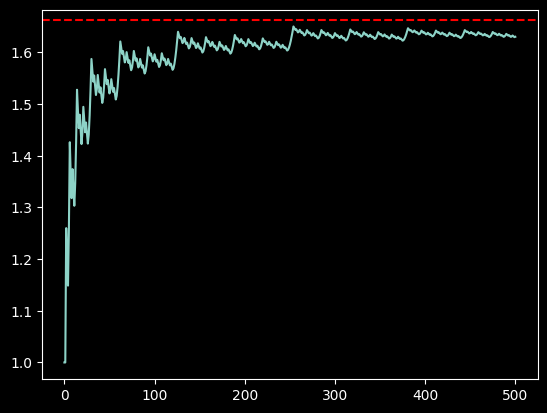

In [ ]:
diff_coeffs = compute_binary_diff_coeffs(r, 967)
gms = compute_cum_GM(diff_coeffs)
plt.plot(gms)

plt.axhline(somos_const, color='r', linestyle='--')
plt.show()

In [ ]:
kuzmin_coeffs = np.load('consts/Kuzmin.npy')
kuzmin_const = compute_num_from_cf(kuzmin_coeffs[:1000])
float(kuzmin_const)

0.581580335882833

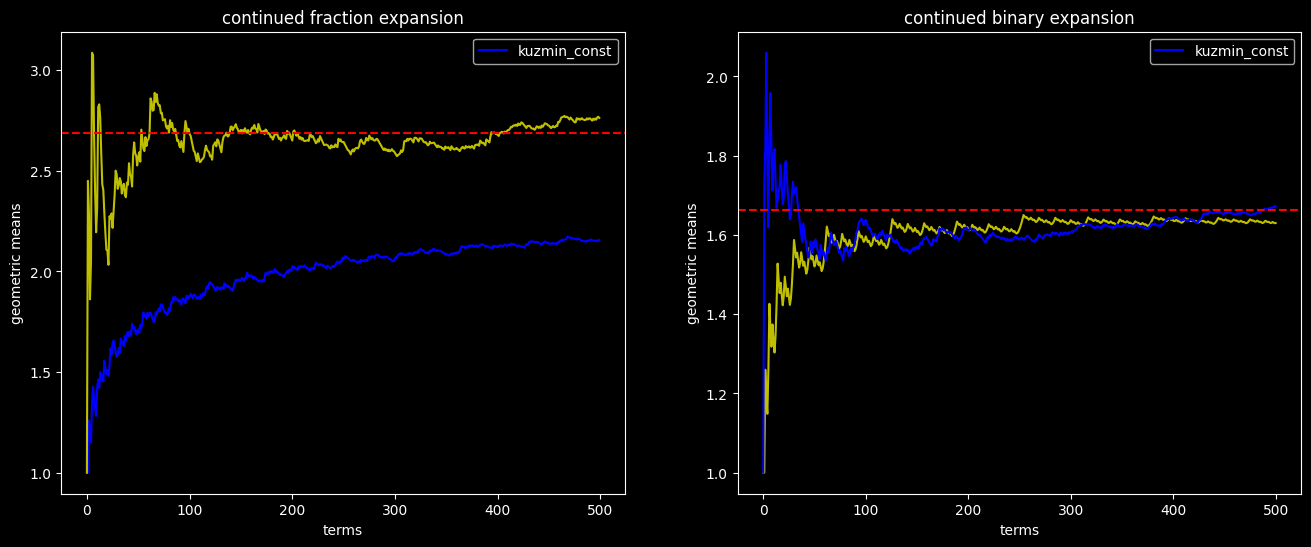

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(16,6))

cf_coeffs = compute_cf(kuzmin_const, 501)
gms = compute_cum_GM(cf_coeffs[1:])
ax[0].plot(gms, label='kuzmin_const', c='b')
cf_coeffs = compute_cf(r, 501)
gms = compute_cum_GM(cf_coeffs[1:])
ax[0].plot(gms, c='y')
ax[0].axhline(K, color='r', linestyle='--')
ax[0].title.set_text('continued fraction expansion')
ax[0].set_xlabel('terms')
ax[0].set_ylabel('geometric means')
ax[0].legend()

diff_coeffs = compute_binary_diff_coeffs(r, 967)
gms = compute_cum_GM(diff_coeffs)
ax[1].plot(gms, c='y')
diff_coeffs = compute_binary_diff_coeffs(kuzmin_const, 1003)
gms = compute_cum_GM(diff_coeffs)
ax[1].plot(gms, label='kuzmin_const', c='b')
ax[1].axhline(somos_const, color='r', linestyle='--')
ax[1].title.set_text('continued binary expansion')
ax[1].set_xlabel('terms')
ax[1].set_ylabel('geometric means')
ax[1].legend()

plt.show()

#### Accelerated convergence.

In [ ]:
@nb.njit
def prob_count_diff(j, k, counts):
  return k*pmf_nb(j) - counts.get(j, 0)

@nb.njit
def compute_accelerated_somos_coeffs(n):
  coeffs = np.zeros(n, dtype=np.int64)
  unreached_val = 1
  counts = nb.typed.Dict.empty(nb.types.int64, nb.types.int64)
  for k in range(1, n+1):
    prob_count_diffs = np.array(
        [prob_count_diff(i, k, counts) for i in range(1, unreached_val+1)])
    most_probable = prob_count_diffs.argmax() + 1
    if most_probable == unreached_val:
      unreached_val += 1
    coeffs[k-1] = most_probable
    counts[most_probable] = counts.get(most_probable, 0) + 1
  return coeffs

In [ ]:
num_steps = 100000
somos_coeffs = compute_accelerated_somos_coeffs(num_steps)
list(somos_coeffs[:25])

[1, 2, 1, 3, 1, 2, 1, 4, 1, 2, 1, 3, 1, 2, 1, 5, 1, 2, 1, 3, 1, 2, 1, 4, 1]

In [ ]:
somos_bin = diff_to_bin(somos_coeffs[:50032])
somos_bin[:25]
print(somos_bin[:50])

[1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1]


In [ ]:
r = frac_bin_to_dec(somos_bin)
float(r)

0.7007354952864049

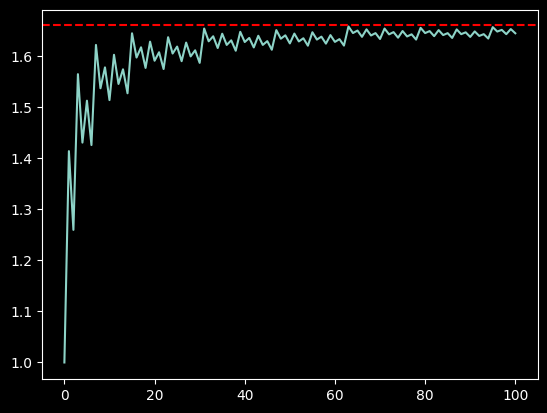

In [ ]:
diff_coeffs = compute_binary_diff_coeffs(r, 198)
gms = compute_cum_GM(diff_coeffs)
plt.plot(gms)

plt.axhline(somos_const, color='r', linestyle='--')
plt.show()